WALKING OURSELVES THROUGH THE TITANIC DATASET TO UNCOVER INSIGHTS USING UNIVARIATE EXPLORATORY DATA ANALYSIS
(TO BE DONE AFTER ASKING THE BASIC QUESTIONS WE DISCUSSED IN THE LAST BLOG: https://medium.com/@priyanshu20032002/before-the-model-understanding-your-data-the-right-way-1e48cd4bf728)

Loading the data.

In [2]:
import pandas as pd
df = pd.read_csv('train.csv')

Looking at the first 5 rows to know what the data looks like.

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


We can see that our data contains both categorical and numerical data.

First we will focus on performing EDA on the categorical data( data that groups information into distinct, mutually exclusive labels or categories rather than numerical measurements)

-COUNTPLOT

Now while analysing data for single variable, you would need to ask questions like what can I get from this or what is the answer that we would want from the question. For example: for the survived couloumn we would want to know how many survived and how many did not?

In [4]:
import seaborn as sns

From the graph we can clearly see what proportion of the people survived and what proportion of the people died.

,count
Survived,
0,549
1,342


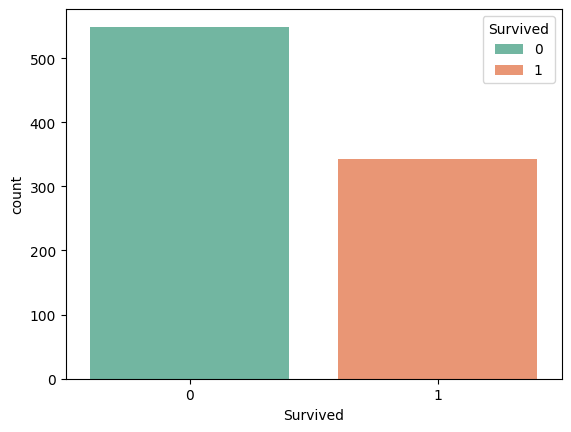

In [5]:
sns.countplot(x=df['Survived'], hue=df['Survived'], palette='Set2')
df['Survived'].value_counts()

From this we can see how many passengers belonged to each category of the class that were there.

,count
Pclass,
3,491
1,216
2,184


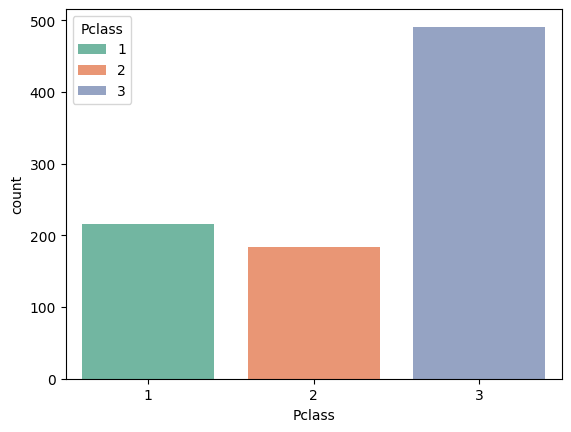

In [6]:
sns.countplot(x= df['Pclass'], hue=df['Pclass'], palette='Set2')
df['Pclass'].value_counts()

Fromn this we can see what the gender ditricution looked like.

,count
Sex,
male,577
female,314


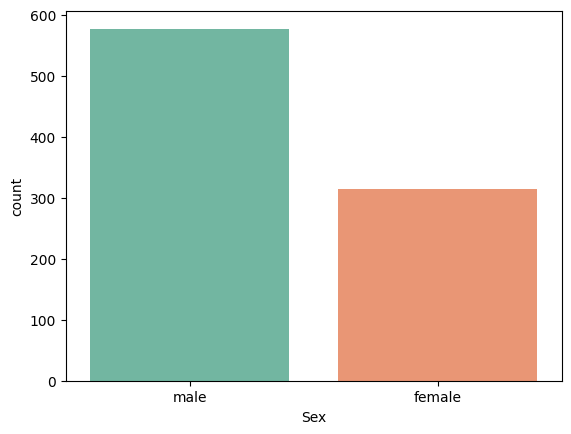

In [7]:
sns.countplot( x = df['Sex'], hue=df['Sex'], palette='Set2')
df['Sex'].value_counts()

And from the final countplot for our categorical data coloumns we can see how many passengers embarked on the journey from each of the three stops that the ship made.

,count
Embarked,
S,644
C,168
Q,77


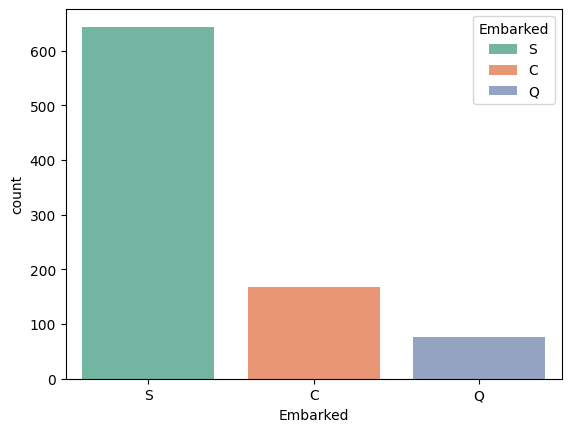

In [8]:
sns.countplot( x = df['Embarked'], hue=df['Embarked'], palette='Set2')
df['Embarked'].value_counts()

If we want the same data in terms of the percentage of each class, we can plot pir charts like the following.

<Axes: ylabel='count'>

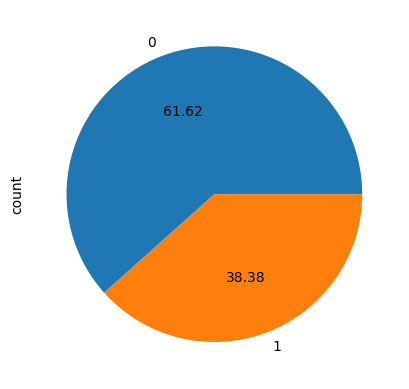

In [9]:
df['Survived'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

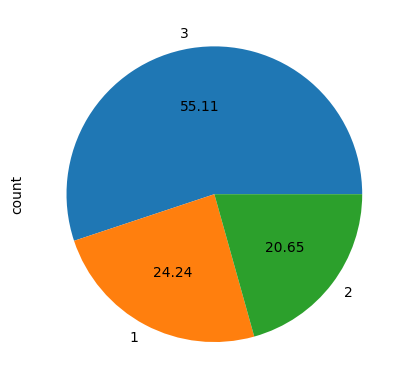

In [10]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

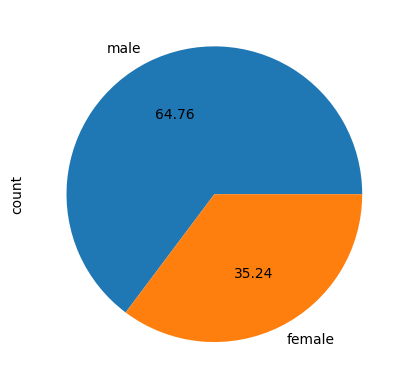

In [11]:
df['Sex'].value_counts().plot(kind='pie',autopct='%.2f')

<Axes: ylabel='count'>

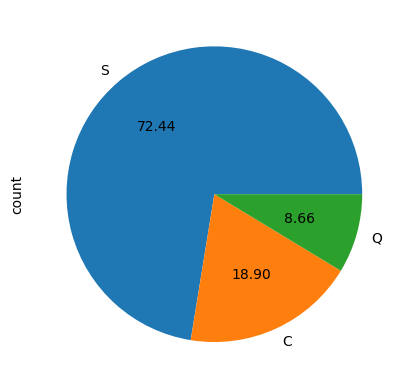

In [12]:
df['Embarked'].value_counts().plot(kind='pie',autopct='%.2f')

You can use any of the countplot or pie charts as per your convinience. A more interesting things come up when we work with numerical data.

Let's now work with the numerical data.

-HISTOGRAM

In [13]:
import matplotlib.pyplot as plt

This tells me the distribution of the age (numerical coloumn) in various bins.

(array([ 54.,  46., 177., 169., 118.,  70.,  45.,  24.,   9.,   2.]),
 array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
        64.084, 72.042, 80.   ]),
 <BarContainer object of 10 artists>)

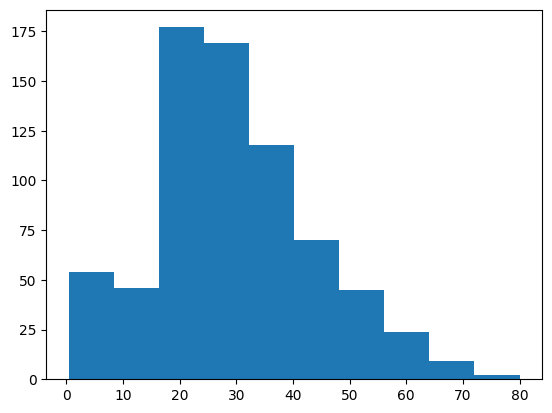

In [14]:
plt.hist(df['Age'])

(array([732., 106.,  31.,   2.,  11.,   6.,   0.,   0.,   0.,   3.]),
 array([  0.     ,  51.23292, 102.46584, 153.69876, 204.93168, 256.1646 ,
        307.39752, 358.63044, 409.86336, 461.09628, 512.3292 ]),
 <BarContainer object of 10 artists>)

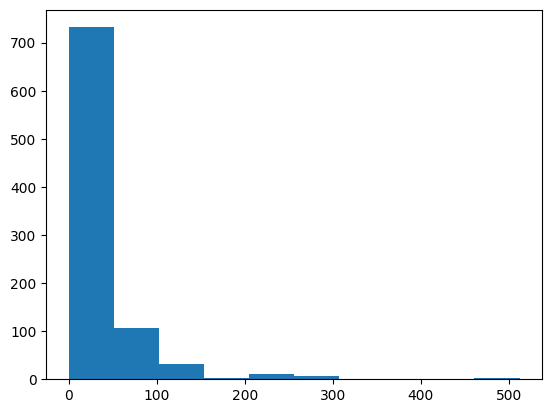

In [15]:
plt.hist(df['Fare'])

-DISTPLOT

Distplot is similar to histogram, it shows the distribution of the data along with a kernel density fucntion. t's a probablity distribution function with probability of the y axis and age on the y-axis.
The graph also tells me wether our data has skewness (asymmetry in a statistical distribution) or not.

/tmp/ipykernel_2740/3255828239.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Age'])


<Axes: xlabel='Age', ylabel='Density'>

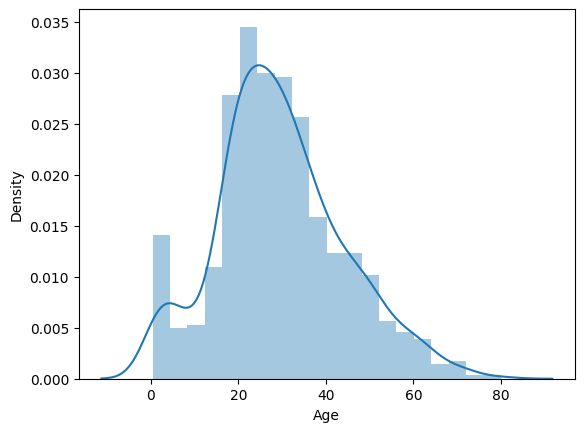

In [24]:
sns.distplot(df['Age'])

-BOXPLOT

This graph would show me the distribution of data based on a 5-number summary.
1) Minimum
2) First quartile(Q1)
3) Median
4) Third Quartile(Q3)
5) Maximum

And any observation beyond the minimum and maximum values fo the dataset are termed as potential outliers, hence identification of potential outliers is also possible with a boxplot.



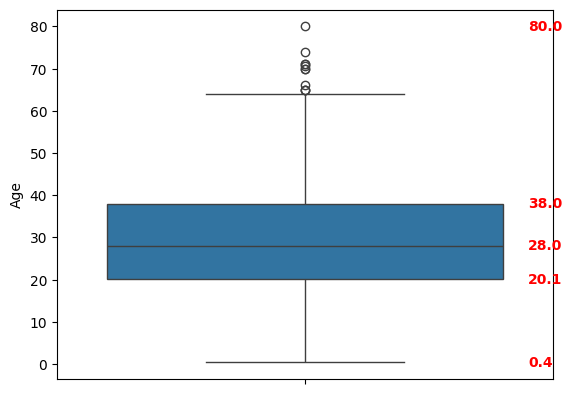

In [25]:
ax = sns.boxplot(y=df['Age'])

# this part of the code is just to write the values across the plotted graph
quantiles = df['Age'].quantile([0,0.25, 0.5, 0.75,1])

for q in quantiles:

    ax.text(x=0.45, y=q, s=f"{q:.1f}", color='red', va='center', fontweight='bold')

Now instead of plotting everything, we can directly get all the stats for a particular numerical coloumn by using the describe function.

In [26]:
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000
